## 1. Importar Bibliotecas Necessárias

In [1]:
# Importar bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# Configurar visualizações
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

## 2. Carregar e Explorar os Dados

Utilizaremos um dataset de churn de clientes de telecomunicações.

In [2]:
# Carregar dataset
url = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/refs/heads/master/data/Telco-Customer-Churn.csv'
df = pd.read_csv(url)

In [3]:

# Visualizar primeiras linhas
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Informações gerais
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
# Estatísticas descritivas
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
# Verificar valores faltantes
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
# Distribuição da variável alvo (Churn)
print(df['Churn'].value_counts())
print(f"\nProporção: {df['Churn'].value_counts(normalize=True)}")

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Proporção: Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


## 3. Preparação dos Dados

In [8]:
# Criar uma cópia do dataframe
df_clean = df.copy()

# Remover coluna de ID do cliente (não é útil para predição)
df_clean = df_clean.drop('customerID', axis=1)

# Converter 'TotalCharges' para numérico (há alguns valores em branco)
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')

# Preencher valores faltantes com a mediana
df_clean['TotalCharges'].fillna(df_clean['TotalCharges'].median(), inplace=True)

# Converter variável alvo (Churn) para binária (0 e 1)
df_clean['Churn'] = (df_clean['Churn'] == 'Yes').astype(int)

print(f"\nForma do dataset: {df_clean.shape}")
print(f"Variável alvo (Churn): {df_clean['Churn'].value_counts().to_dict()}")
print("Dataset após limpeza:")
df_clean.head()



Forma do dataset: (7043, 20)
Variável alvo (Churn): {0: 5174, 1: 1869}
Dataset após limpeza:


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


## 4. Engenharia de Features

In [9]:
# Identificar variáveis categóricas e numéricas
categorical_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
numeric_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_cols.remove('Churn')  # Remover a variável alvo da lista de numéricas

print(f"Variáveis categóricas ({len(categorical_cols)}): {categorical_cols}")
print(f"Variáveis numéricas ({len(numeric_cols)}): {numeric_cols}")

Variáveis categóricas (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Variáveis numéricas (4): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [10]:
# Codificar variáveis categóricas
df_encoded = df_clean.copy()
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le
    print(f"\n{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

print("\n" + "="*80)
print("Dataset após codificação:")
df_encoded.head()


gender: {'Female': np.int64(0), 'Male': np.int64(1)}

Partner: {'No': np.int64(0), 'Yes': np.int64(1)}

Dependents: {'No': np.int64(0), 'Yes': np.int64(1)}

PhoneService: {'No': np.int64(0), 'Yes': np.int64(1)}

MultipleLines: {'No': np.int64(0), 'No phone service': np.int64(1), 'Yes': np.int64(2)}

InternetService: {'DSL': np.int64(0), 'Fiber optic': np.int64(1), 'No': np.int64(2)}

OnlineSecurity: {'No': np.int64(0), 'No internet service': np.int64(1), 'Yes': np.int64(2)}

OnlineBackup: {'No': np.int64(0), 'No internet service': np.int64(1), 'Yes': np.int64(2)}

DeviceProtection: {'No': np.int64(0), 'No internet service': np.int64(1), 'Yes': np.int64(2)}

TechSupport: {'No': np.int64(0), 'No internet service': np.int64(1), 'Yes': np.int64(2)}

StreamingTV: {'No': np.int64(0), 'No internet service': np.int64(1), 'Yes': np.int64(2)}

StreamingMovies: {'No': np.int64(0), 'No internet service': np.int64(1), 'Yes': np.int64(2)}

Contract: {'Month-to-month': np.int64(0), 'One year': np.in

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


## 5. Dividir Dados em Treino, Validação e Teste

Usaremos a proporção: 70% treino, 10% validação, 20% teste

In [11]:
# Separar features e target
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

qt_samples_test = int(0.20 * len(X))
qt_samples_val = int(0.10 * len(X))

# Primeira divisão: 70% treino + validação, 30% teste
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, 
    test_size=qt_samples_test, 
    random_state=42, 
    stratify=y
)

# Segunda divisão: dividir os 80% em 70% treino e 10% validação
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=qt_samples_val,
    random_state=42,
    stratify=y_temp
)

print("Divisão dos dados:")
print(f"Treino: {X_train.shape[0]} amostras ({X_train.shape[0]/len(X)*100:.2f}%)")
print(f"Validação: {X_val.shape[0]} amostras ({X_val.shape[0]/len(X)*100:.2f}%)")
print(f"Teste: {X_test.shape[0]} amostras ({X_test.shape[0]/len(X)*100:.2f}%)")

print("\n" + "="*80)
print("Distribuição do target em cada conjunto:")
print(f"\nTreino - Churn=0: {(y_train==0).sum()} {round((y_train==0).sum()/len(y_train)*100,1)}% | Churn=1: {(y_train==1).sum()}")
print(f"Validação - Churn=0: {(y_val==0).sum()} {round((y_val==0).sum()/len(y_val)*100,1)}% | Churn=1: {(y_val==1).sum()}")
print(f"Teste - Churn=0: {(y_test==0).sum()} {round((y_test==0).sum()/len(y_test)*100,1)}% | Churn=1: {(y_test==1).sum()}")

Divisão dos dados:
Treino: 4931 amostras (70.01%)
Validação: 704 amostras (10.00%)
Teste: 1408 amostras (19.99%)

Distribuição do target em cada conjunto:

Treino - Churn=0: 3623 73.5% | Churn=1: 1308
Validação - Churn=0: 517 73.4% | Churn=1: 187
Teste - Churn=0: 1034 73.4% | Churn=1: 374


## 6. Escalar Features Numéricas

In [12]:
# Obs. O XGBoost não requer padronização/normalização dos dados, pois é baseado em árvores de decisão.
# entretanto, para fins didáticos, vamos aplicar a padronização.

In [13]:
# Aplicar StandardScaler nas features numéricas
scaler = StandardScaler()

# Escalar treino
X_train_scaled = X_train.copy()
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])

# Escalar validação
X_val_scaled = X_val.copy()
X_val_scaled[numeric_cols] = scaler.transform(X_val[numeric_cols])

# Escalar teste
X_test_scaled = X_test.copy()
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

print("Features escaladas!")
print(f"Treino escalado:")
X_train_scaled.head()

Features escaladas!
Treino escalado:


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
4130,0,-0.438752,0,0,-0.906883,0,1,0,0,2,0,2,0,0,0,0,2,-0.941745,-0.839599
6880,0,-0.438752,1,1,1.613195,1,2,2,1,1,1,1,1,1,2,0,0,-1.307003,-0.221993
5391,0,-0.438752,0,0,-1.069468,0,1,0,0,0,0,2,2,2,1,1,3,-0.512030,-0.891337
1611,0,-0.438752,1,0,1.613195,1,2,0,2,2,2,2,2,2,2,1,0,0.866364,1.823621
3436,1,-0.438752,0,0,-0.297186,1,0,2,1,1,1,1,1,1,1,1,0,-1.495417,-0.777417


## 7. Treinar Modelo XGBoost

In [14]:
# Criar e treinar modelo XGBoost
modelo_xgb = xgb.XGBClassifier(
    n_estimators=100,           # Número de árvores
    max_depth=6,                # Profundidade máxima da árvore
    learning_rate=0.1,          # Taxa de aprendizado
    subsample=0.8,              # Fração de amostras para treinar cada árvore
    colsample_bytree=0.8,       # Fração de features para cada árvore
    objective='binary:logistic', # Classificação binária
    random_state=42,
    verbosity=1
)

# Treinar no conjunto de treino
print("Treinando modelo XGBoost...")
modelo_xgb.fit(
    X_train_scaled, y_train,
    eval_set=[(X_train_scaled, y_train), (X_val_scaled, y_val)],
    verbose=True
)

print("Modelo treinado com sucesso!")

Treinando modelo XGBoost...
[0]	validation_0-logloss:0.54813	validation_1-logloss:0.55308
[1]	validation_0-logloss:0.52221	validation_1-logloss:0.53156
[2]	validation_0-logloss:0.50100	validation_1-logloss:0.51376
[3]	validation_0-logloss:0.48311	validation_1-logloss:0.50031
[4]	validation_0-logloss:0.46796	validation_1-logloss:0.48860
[5]	validation_0-logloss:0.45443	validation_1-logloss:0.47922
[6]	validation_0-logloss:0.44267	validation_1-logloss:0.47197
[7]	validation_0-logloss:0.43252	validation_1-logloss:0.46591
[8]	validation_0-logloss:0.42350	validation_1-logloss:0.46126
[9]	validation_0-logloss:0.41557	validation_1-logloss:0.45712
[10]	validation_0-logloss:0.40922	validation_1-logloss:0.45314
[11]	validation_0-logloss:0.40287	validation_1-logloss:0.44817
[12]	validation_0-logloss:0.39720	validation_1-logloss:0.44498
[13]	validation_0-logloss:0.39179	validation_1-logloss:0.44101
[14]	validation_0-logloss:0.38732	validation_1-logloss:0.43928
[15]	validation_0-logloss:0.38333	val

## 8. Fazer Predições

In [15]:
y_test_pred = modelo_xgb.predict(X_test_scaled)

# Probabilidades
y_test_pred_proba = modelo_xgb.predict_proba(X_test_scaled)[:, 1]

print("Predições realizadas!")
print(f"\nExemplos de predições (teste):")
print(f"Primeiros 10 valores reais: {y_test.values[:10]}")
print(f"Primeiros 10 predições: {y_test_pred[:10]}")
print(f"Primeiros 10 probabilidades: {y_test_pred_proba[:10].round(4)}")

Predições realizadas!

Exemplos de predições (teste):
Primeiros 10 valores reais: [0 0 0 0 0 0 0 0 0 1]
Primeiros 10 predições: [1 0 0 1 0 0 0 0 1 1]
Primeiros 10 probabilidades: [0.6914 0.3525 0.0052 0.9149 0.0635 0.019  0.0349 0.0582 0.7422 0.5394]


## 9. Avaliar Modelo - Métricas de Desempenho

In [16]:
y_train_pred = modelo_xgb.predict(X_train_scaled)
y_val_pred = modelo_xgb.predict(X_val_scaled)

y_train_pred_proba = modelo_xgb.predict_proba(X_train_scaled)[:, 1]
y_val_pred_proba = modelo_xgb.predict_proba(X_val_scaled)[:, 1]

In [17]:
# Função para calcular métricas
def avaliar_modelo(y_true, y_pred, y_pred_proba, conjunto_nome):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_pred_proba)
    
    print(f"\n{'='*60}")
    print(f"MÉTRICAS - {conjunto_nome}")
    print(f"{'='*60}")
    print(f"Acurácia:     {acc:.4f} ({acc*100:.2f}%)")
    print(f"Precisão:     {prec:.4f} ({prec*100:.2f}%)")
    print(f"Recall:       {rec:.4f} ({rec*100:.2f}%)")
    print(f"F1-Score:     {f1:.4f}")
    print(f"ROC-AUC:      {roc_auc:.4f}")
    
    return {'Acurácia': acc, 'Precisão': prec, 'Recall': rec, 'F1': f1, 'ROC-AUC': roc_auc}

# Avaliar em todos os conjuntos
metricas_train = avaliar_modelo(y_train, y_train_pred, y_train_pred_proba, "TREINO")
metricas_val = avaliar_modelo(y_val, y_val_pred, y_val_pred_proba, "VALIDAÇÃO")
metricas_test = avaliar_modelo(y_test, y_test_pred, y_test_pred_proba, "TESTE")


MÉTRICAS - TREINO
Acurácia:     0.8856 (88.56%)
Precisão:     0.8286 (82.86%)
Recall:       0.7171 (71.71%)
F1-Score:     0.7689
ROC-AUC:      0.9513

MÉTRICAS - VALIDAÇÃO
Acurácia:     0.7898 (78.98%)
Precisão:     0.6327 (63.27%)
Recall:       0.4973 (49.73%)
F1-Score:     0.5569
ROC-AUC:      0.8269

MÉTRICAS - TESTE
Acurácia:     0.7976 (79.76%)
Precisão:     0.6459 (64.59%)
Recall:       0.5267 (52.67%)
F1-Score:     0.5803
ROC-AUC:      0.8365


## 10. Matriz de Confusão

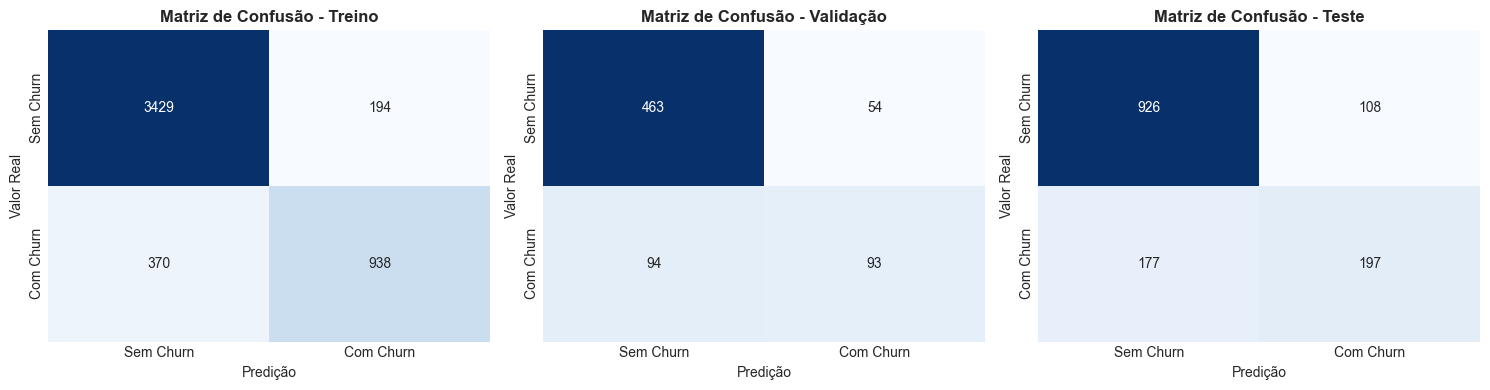


Interpretação da Matriz de Confusão:
- Verdadeiros Negativos (TN): Clientes sem churn preditos corretamente
- Falsos Positivos (FP): Clientes sem churn preditos como churn
- Falsos Negativos (FN): Clientes com churn preditos como sem churn
- Verdadeiros Positivos (TP): Clientes com churn preditos corretamente


In [18]:
# Criar figura com matrizes de confusão
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

conjuntos = [
    (y_train, y_train_pred, "Treino"),
    (y_val, y_val_pred, "Validação"),
    (y_test, y_test_pred, "Teste")
]

for idx, (y_true, y_pred, nome) in enumerate(conjuntos):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], cbar=False)
    axes[idx].set_title(f"Matriz de Confusão - {nome}", fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Valor Real')
    axes[idx].set_xlabel('Predição')
    axes[idx].set_xticklabels(['Sem Churn', 'Com Churn'])
    axes[idx].set_yticklabels(['Sem Churn', 'Com Churn'])

plt.tight_layout()
plt.show()

print("\nInterpretação da Matriz de Confusão:")
print("- Verdadeiros Negativos (TN): Clientes sem churn preditos corretamente")
print("- Falsos Positivos (FP): Clientes sem churn preditos como churn")
print("- Falsos Negativos (FN): Clientes com churn preditos como sem churn")
print("- Verdadeiros Positivos (TP): Clientes com churn preditos corretamente")

## 11. Curva ROC

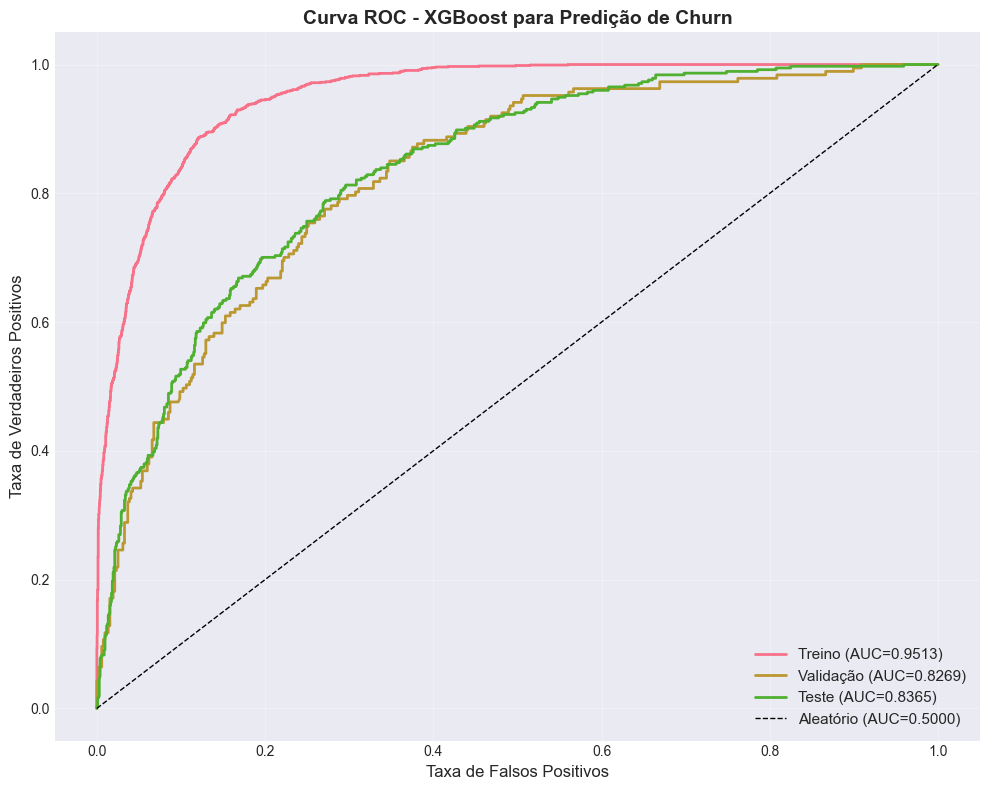

A curva ROC mostra a relação entre sensibilidade (TPR) e especificidade (1-FPR)
AUC > 0.7: Bom desempenho
AUC > 0.8: Excelente desempenho


In [19]:
# Calcular curva ROC para todos os conjuntos
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_pred_proba)
fpr_val, tpr_val, _ = roc_curve(y_val, y_val_pred_proba)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_pred_proba)

# Plotar curvas ROC
fig, ax = plt.subplots(figsize=(10, 8))

ax.plot(fpr_train, tpr_train, label=f'Treino (AUC={metricas_train["ROC-AUC"]:.4f})', linewidth=2)
ax.plot(fpr_val, tpr_val, label=f'Validação (AUC={metricas_val["ROC-AUC"]:.4f})', linewidth=2)
ax.plot(fpr_test, tpr_test, label=f'Teste (AUC={metricas_test["ROC-AUC"]:.4f})', linewidth=2)
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Aleatório (AUC=0.5000)')

ax.set_xlabel('Taxa de Falsos Positivos', fontsize=12)
ax.set_ylabel('Taxa de Verdadeiros Positivos', fontsize=12)
ax.set_title('Curva ROC - XGBoost para Predição de Churn', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("A curva ROC mostra a relação entre sensibilidade (TPR) e especificidade (1-FPR)")
print("AUC > 0.7: Bom desempenho")
print("AUC > 0.8: Excelente desempenho")

## 12. Importância das Features

In [20]:
# XGBoost Feature Importance
# Padrão: GAIN
# Redução total de perda (loss) causada pela feature
# Calcula: Ganho médio quando a feature é usada em divisões
# Fórmula: Ganho = Loss_pai - (Loss_esquerda + Loss_direita)
# Interpretação: Features com maior redução de erro são mais importantes

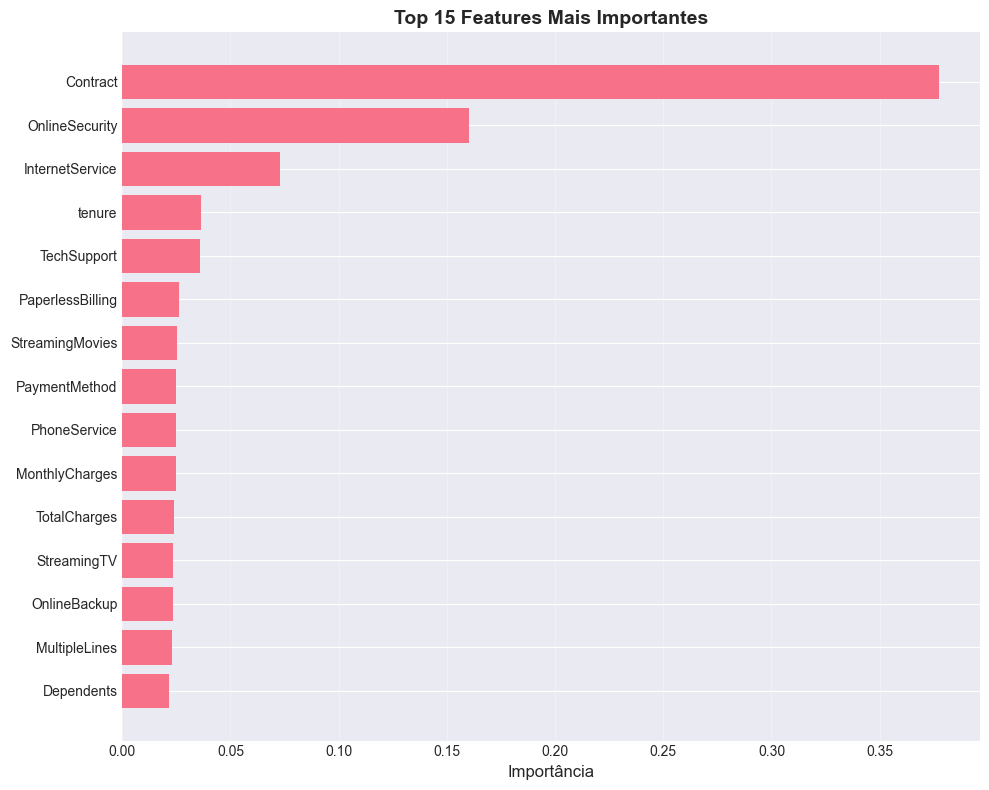


As 15 features mais importantes representam 92.54% da importância total


In [21]:
# Obter importância das features
feature_importance = modelo_xgb.feature_importances_
feature_names = X_train.columns

# Criar dataframe com importância
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importância': feature_importance
}).sort_values('Importância', ascending=False)


# Plotar top 15 features
fig, ax = plt.subplots(figsize=(10, 8))
top_n = 15
importance_top = importance_df.head(top_n)

ax.barh(range(len(importance_top)), importance_top['Importância'].values)
ax.set_yticks(range(len(importance_top)))
ax.set_yticklabels(importance_top['Feature'].values)
ax.invert_yaxis()
ax.set_xlabel('Importância', fontsize=12)
ax.set_title(f'Top {top_n} Features Mais Importantes', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nAs {top_n} features mais importantes representam {importance_top['Importância'].sum():.2%} da importância total")

## 13. Relatório de Classificação Detalhado

In [22]:
# Relatório detalhado para o conjunto de teste
print("RELATÓRIO DE CLASSIFICAÇÃO - CONJUNTO DE TESTE")
print("="*80)
print(classification_report(y_test, y_test_pred, target_names=['Sem Churn', 'Com Churn']))

print("\nInterpretação:")
print("- Precision: Dentre as predições de churn, quantas estavam corretas?")
print("- Recall (Sensibilidade): Dentre os clientes que fizeram churn, quantos foram identificados?")
print("- F1-Score: Média harmônica entre Precision e Recall")
print("- Support: Número de amostras em cada classe")

RELATÓRIO DE CLASSIFICAÇÃO - CONJUNTO DE TESTE
              precision    recall  f1-score   support

   Sem Churn       0.84      0.90      0.87      1034
   Com Churn       0.65      0.53      0.58       374

    accuracy                           0.80      1408
   macro avg       0.74      0.71      0.72      1408
weighted avg       0.79      0.80      0.79      1408


Interpretação:
- Precision: Dentre as predições de churn, quantas estavam corretas?
- Recall (Sensibilidade): Dentre os clientes que fizeram churn, quantos foram identificados?
- F1-Score: Média harmônica entre Precision e Recall
- Support: Número de amostras em cada classe


## 14. Exemplos de Predições

In [23]:
# Criar dataframe com predições e probabilidades no conjunto de teste
resultados_teste = pd.DataFrame({
    'Churn_Real': y_test.values,
    'Churn_Predito': y_test_pred,
    'Probabilidade_Churn': y_test_pred_proba,
    'Probabilidade_Sem_Churn': 1 - y_test_pred_proba
})

# Adicionar features originais
resultados_teste = pd.concat([X_test_scaled.reset_index(drop=True), resultados_teste], axis=1)

# Mostrar exemplos de diferentes cenários
print("EXEMPLOS DE PREDIÇÕES - CONJUNTO DE TESTE")
print("="*100)

print("\n1. Predições CORRETAS de CHURN (Verdadeiros Positivos):")
corretos_churn = resultados_teste[(resultados_teste['Churn_Real']==1) & (resultados_teste['Churn_Predito']==1)]
print(corretos_churn[['Churn_Real', 'Churn_Predito', 'Probabilidade_Churn']].head(5))

print("\n2. Predições CORRETAS de SEM CHURN (Verdadeiros Negativos):")
corretos_sem_churn = resultados_teste[(resultados_teste['Churn_Real']==0) & (resultados_teste['Churn_Predito']==0)]
print(corretos_sem_churn[['Churn_Real', 'Churn_Predito', 'Probabilidade_Churn']].head(5))

print("\n3. Predições INCORRETAS (Erros do Modelo):")
erros = resultados_teste[resultados_teste['Churn_Real'] != resultados_teste['Churn_Predito']]
print(erros[['Churn_Real', 'Churn_Predito', 'Probabilidade_Churn']].head(10))
print(f"\nTotal de erros: {len(erros)} de {len(resultados_teste)} ({len(erros)/len(resultados_teste)*100:.2f}%)")

EXEMPLOS DE PREDIÇÕES - CONJUNTO DE TESTE

1. Predições CORRETAS de CHURN (Verdadeiros Positivos):
    Churn_Real  Churn_Predito  Probabilidade_Churn
9            1              1             0.539436
13           1              1             0.712055
20           1              1             0.523898
36           1              1             0.659488
49           1              1             0.843954

2. Predições CORRETAS de SEM CHURN (Verdadeiros Negativos):
   Churn_Real  Churn_Predito  Probabilidade_Churn
1           0              0             0.352528
2           0              0             0.005223
4           0              0             0.063524
5           0              0             0.018993
6           0              0             0.034937

3. Predições INCORRETAS (Erros do Modelo):
    Churn_Real  Churn_Predito  Probabilidade_Churn
0            0              1             0.691372
3            0              1             0.914906
8            0              1        

## 15. Comparação de Desempenho entre Conjuntos

COMPARAÇÃO DE DESEMPENHO ENTRE CONJUNTOS
          Treino  Validação   Teste
Acurácia  0.8856     0.7898  0.7976
Precisão  0.8286     0.6327  0.6459
Recall    0.7171     0.4973  0.5267
F1        0.7689     0.5569  0.5803
ROC-AUC   0.9513     0.8269  0.8365


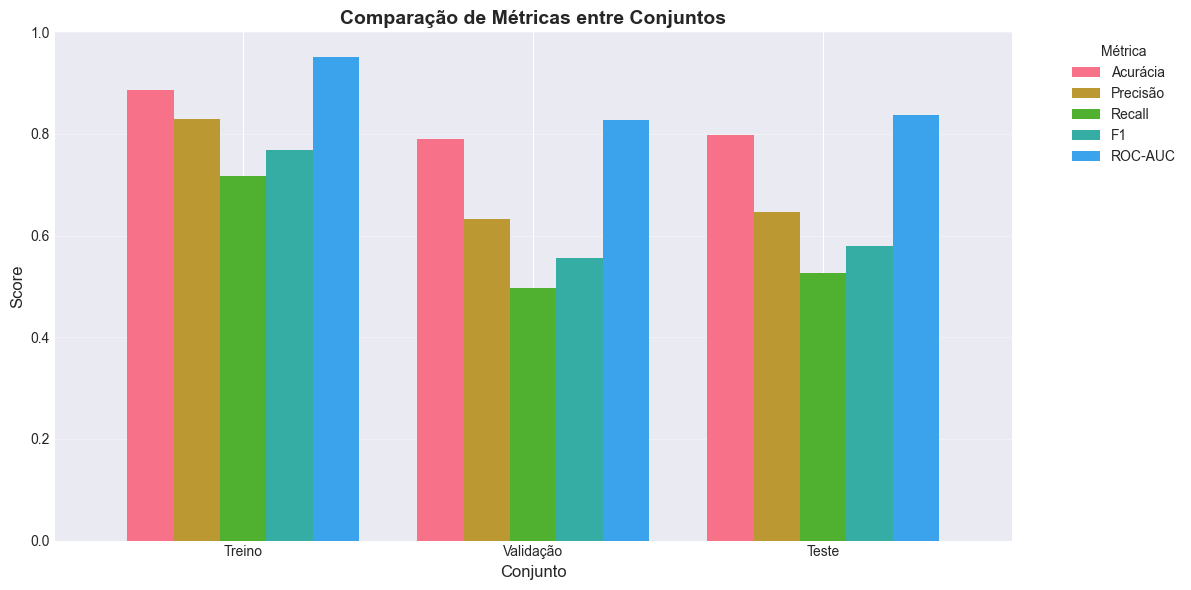


Interpretação:
- Se Treino >> Teste: Possível overfitting
- Se Treino ≈ Validação ≈ Teste: Modelo generaliza bem
- Se todos são baixos: Underfitting


In [24]:
# Criar dataframe com comparação de métricas
comparacao_df = pd.DataFrame({
    'Treino': metricas_train,
    'Validação': metricas_val,
    'Teste': metricas_test
})

print("COMPARAÇÃO DE DESEMPENHO ENTRE CONJUNTOS")
print("="*80)
print(comparacao_df.round(4))

# Visualizar comparação
fig, ax = plt.subplots(figsize=(12, 6))
comparacao_df.T.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('Comparação de Métricas entre Conjuntos', fontsize=14, fontweight='bold')
ax.set_ylabel('Score', fontsize=12)
ax.set_xlabel('Conjunto', fontsize=12)
ax.legend(title='Métrica', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_ylim([0, 1])
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nInterpretação:")
print("- Se Treino >> Teste: Possível overfitting")
print("- Se Treino ≈ Validação ≈ Teste: Modelo generaliza bem")
print("- Se todos são baixos: Underfitting")